In [13]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import cv2
from pathlib import Path
from sklearn.metrics import cohen_kappa_score

carpeta_labeled = Path("../data/labeled")
carpeta_videos = Path("../data/raw")   # ajustado: los videos están aquí directo

UMBRAL_CIERRE = 0.5
UMBRAL_BOSTEZO = 3.0

In [14]:
xmls_a = sorted(carpeta_labeled.glob("*_A.xml"))
nombres_base = [p.stem.replace("_A", "") for p in xmls_a]

print(f"Se encontraron {len(nombres_base)} videos con par A/B:")
for n in nombres_base:
    existe_b = (carpeta_labeled / f"{n}_B.xml").exists()
    print(f"  {n} {'✓' if existe_b else '✗ FALTA EL B'}")

Se encontraron 18 videos con par A/B:
  V1_video1_normal ✓
  V1_video2_pocaluz ✓
  V2_video1_normal ✓
  V2_video2_lentes ✓
  V3_video1_normal ✓
  V3_video2_lentes ✓
  V4_video1_normal ✓
  V4_video2_pocaluz ✓
  V5_video1_normal ✓
  V5_video2_pocaluz ✓
  V6_video1_normal ✓
  V6_video2_pocaluz ✓
  V7_video1_normal ✓
  V7_video2_pocaluz ✓
  V8_video1_normal ✓
  V8_video2_lentes ✓
  V9_video1_normal ✓
  V9_video2_pocaluz ✓


In [15]:
def obtener_fps_frames(nombre_video):
    candidatos = list(carpeta_videos.glob(f"{nombre_video}.*"))
    if not candidatos:
        raise FileNotFoundError(f"No se encontró el video para {nombre_video}")
    cap = cv2.VideoCapture(str(candidatos[0]))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return fps, total

def xml_a_eventos(ruta_xml, fps):
    tree = ET.parse(ruta_xml)
    eventos = []
    for track in tree.getroot().findall(".//track"):
        label = track.get("label")
        boxes = track.findall("box")
        inicio = int(boxes[0].get("frame"))
        fin = int(boxes[-1].get("frame"))
        duracion = (fin - inicio) / fps
        eventos.append({"etiqueta": label, "frame_inicio": inicio, "frame_fin": fin, "duracion_seg": round(duracion, 2)})
    return eventos

def xml_a_vector(ruta_xml, etiqueta, total_frames):
    tree = ET.parse(ruta_xml)
    vector = np.zeros(total_frames, dtype=int)
    for track in tree.getroot().findall(".//track"):
        if track.get("label") != etiqueta:
            continue
        boxes = track.findall("box")
        inicio = int(boxes[0].get("frame"))
        fin = int(boxes[-1].get("frame"))
        vector[inicio:fin+1] = 1
    return vector

def validar_evento(etiqueta, duracion):
    if etiqueta == "cierre_ocular":
        return duracion >= UMBRAL_CIERRE
    elif etiqueta == "bostezo":
        return duracion >= UMBRAL_BOSTEZO
    return False

In [26]:
tabla_eventos_global = []
vectores_cierre_a, vectores_cierre_b = [], []
vectores_bostezo_a, vectores_bostezo_b = [], []
resumen_por_video = []

for nombre in nombres_base:
    ruta_a = carpeta_labeled / f"{nombre}_A.xml"
    ruta_b = carpeta_labeled / f"{nombre}_B.xml"

    fps, total_frames = obtener_fps_frames(nombre)

    eventos_a = xml_a_eventos(ruta_a, fps)
    for e in eventos_a:
        e["video"] = nombre
        e["etiquetador"] = "A"
        e["valido"] = validar_evento(e["etiqueta"], e["duracion_seg"])
        tabla_eventos_global.append(e)

    eventos_b = xml_a_eventos(ruta_b, fps)
    for e in eventos_b:
        e["video"] = nombre
        e["etiquetador"] = "B"
        e["valido"] = validar_evento(e["etiqueta"], e["duracion_seg"])
        tabla_eventos_global.append(e)

    v_a_c = xml_a_vector(ruta_a, "cierre_ocular", total_frames)
    v_b_c = xml_a_vector(ruta_b, "cierre_ocular", total_frames)
    v_a_y = xml_a_vector(ruta_a, "bostezo", total_frames)
    v_b_y = xml_a_vector(ruta_b, "bostezo", total_frames)

    vectores_cierre_a.append(v_a_c); vectores_cierre_b.append(v_b_c)
    vectores_bostezo_a.append(v_a_y); vectores_bostezo_b.append(v_b_y)

    kappa_c = cohen_kappa_score(v_a_c, v_b_c) if len(set(v_a_c)|set(v_b_c)) > 1 else np.nan
    kappa_y = cohen_kappa_score(v_a_y, v_b_y) if len(set(v_a_y)|set(v_b_y)) > 1 else np.nan
    resumen_por_video.append({"video": nombre, "kappa_cierre": kappa_c, "kappa_bostezo": kappa_y,
                               "n_eventos_A": len(eventos_a), "n_eventos_B": len(eventos_b)})

df_eventos_global = pd.DataFrame(tabla_eventos_global)
df_resumen_kappa = pd.DataFrame(resumen_por_video)

print("Eventos totales registrados:", len(df_eventos_global))
print(df_resumen_kappa)

Eventos totales registrados: 187
                video  kappa_cierre  kappa_bostezo  n_eventos_A  n_eventos_B
0    V1_video1_normal      0.908992       0.930985            5            5
1   V1_video2_pocaluz      0.925785       0.904687            5            5
2    V2_video1_normal      0.929500       0.928868            4            4
3    V2_video2_lentes      0.945844       0.937520            4            4
4    V3_video1_normal      0.816376       0.857716           13           12
5    V3_video2_lentes      0.843423       0.911114            9            9
6    V4_video1_normal      0.710130       0.880321            5            4
7   V4_video2_pocaluz      0.840820       0.927040            3            3
8    V5_video1_normal      0.847792       0.767931            4            4
9   V5_video2_pocaluz      0.825533       0.447179            4            3
10   V6_video1_normal      0.918207       0.766696            6            6
11  V6_video2_pocaluz      0.844521       0

In [27]:
vector_global_a_cierre = np.concatenate(vectores_cierre_a)
vector_global_b_cierre = np.concatenate(vectores_cierre_b)
vector_global_a_bostezo = np.concatenate(vectores_bostezo_a)
vector_global_b_bostezo = np.concatenate(vectores_bostezo_b)

kappa_global_cierre = cohen_kappa_score(vector_global_a_cierre, vector_global_b_cierre)
kappa_global_bostezo = cohen_kappa_score(vector_global_a_bostezo, vector_global_b_bostezo)

print(f"Kappa GLOBAL - cierre_ocular: {kappa_global_cierre:.3f}")
print(f"Kappa GLOBAL - bostezo: {kappa_global_bostezo:.3f}")

Kappa GLOBAL - cierre_ocular: 0.887
Kappa GLOBAL - bostezo: 0.878


In [28]:
Path("../results/ground_truth").mkdir(parents=True, exist_ok=True)
df_eventos_global.to_csv("../results/ground_truth/eventos_todos_los_videos.csv", index=False)
df_resumen_kappa.to_csv("../results/ground_truth/resumen_kappa_por_video.csv", index=False)

pd.DataFrame({
    "indicador": ["Kappa global - cierre_ocular", "Kappa global - bostezo"],
    "valor": [kappa_global_cierre, kappa_global_bostezo]
}).to_csv("../results/ground_truth/kappa_global.csv", index=False)

print("Todo guardado en results/ground_truth/")

Todo guardado en results/ground_truth/


In [1]:
import pandas as pd
import cv2
from pathlib import Path

df_eventos = pd.read_csv("../results/ground_truth/eventos_todos_los_videos.csv")
carpeta_videos = Path("../data/raw")

filas_tabla20 = []
for voluntario in sorted(set(v.split("_")[0] for v in df_eventos["video"].unique())):
    fila = {"Voluntario": voluntario}
    for i, sufijo in enumerate(["video1", "video2"], start=1):
        videos_v = [v for v in df_eventos["video"].unique() if v.startswith(f"{voluntario}_{sufijo}")]
        if not videos_v:
            fila[f"Duracion_V{i}"] = "No grabado"
            fila[f"CierresBostezos_V{i}"] = "No grabado"
            continue
        nombre_video = videos_v[0]

        # Duración real del video
        candidatos = list(carpeta_videos.glob(f"{nombre_video}.*"))
        cap = cv2.VideoCapture(str(candidatos[0]))
        fps = cap.get(cv2.CAP_PROP_FPS)
        frames = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        cap.release()
        duracion_seg = frames / fps

        # Conteo de eventos VÁLIDOS (etiquetador A, que usamos como referencia) para este video
        sub = df_eventos[(df_eventos["video"] == nombre_video) & (df_eventos["etiquetador"] == "A") & (df_eventos["valido"])]
        n_cierres = (sub["etiqueta"] == "cierre_ocular").sum()
        n_bostezos = (sub["etiqueta"] == "bostezo").sum()

        fila[f"Duracion_V{i}"] = f"{duracion_seg:.0f} s"
        fila[f"CierresBostezos_V{i}"] = f"{n_cierres} cierres / {n_bostezos} bostezos"
    filas_tabla20.append(fila)

df_tabla20 = pd.DataFrame(filas_tabla20)
print(df_tabla20.to_string(index=False))
df_tabla20.to_csv("../results/tabla20_caracteristicas_videos.csv", index=False)

Voluntario Duracion_V1     CierresBostezos_V1 Duracion_V2     CierresBostezos_V2
        V1        78 s 3 cierres / 2 bostezos        62 s 3 cierres / 2 bostezos
        V2        70 s 3 cierres / 1 bostezos        66 s 3 cierres / 1 bostezos
        V3       124 s 7 cierres / 5 bostezos       122 s 6 cierres / 3 bostezos
        V4        35 s 2 cierres / 1 bostezos        31 s 1 cierres / 1 bostezos
        V5        57 s 3 cierres / 0 bostezos        39 s 2 cierres / 0 bostezos
        V6        66 s 3 cierres / 2 bostezos        84 s 3 cierres / 2 bostezos
        V7        42 s 3 cierres / 0 bostezos        51 s 3 cierres / 0 bostezos
        V8        77 s 3 cierres / 1 bostezos        64 s 2 cierres / 2 bostezos
        V9        62 s 3 cierres / 2 bostezos        66 s 3 cierres / 2 bostezos


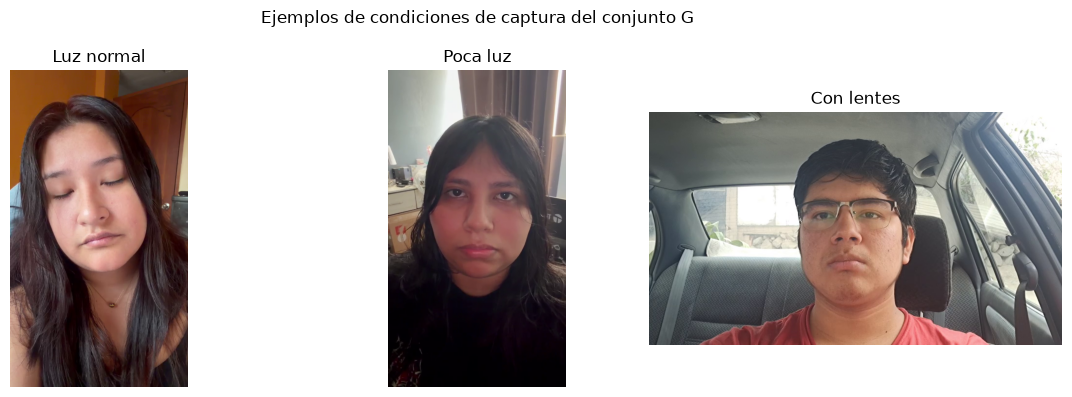

In [4]:
import cv2
import matplotlib.pyplot as plt

videos = [
    "../data/raw/V2_video1_normal.mp4",
    "../data/raw/V1_video2_pocaluz.mp4",
    "../data/raw/V3_video2_lentes.mp4"
]
titulos = [
    "Luz normal",
    "Poca luz",
    "Con lentes"
]

imagenes = []

for video in videos:
    cap = cv2.VideoCapture(video)
    total = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )
    cap.set(
        cv2.CAP_PROP_POS_FRAMES,
        total//2
    )
    ret, frame = cap.read()
    cap.release()
    if ret:
        frame = cv2.cvtColor(
            frame,
            cv2.COLOR_BGR2RGB
        )
        imagenes.append(frame)
plt.figure(figsize=(12,4))
for i,img in enumerate(imagenes):
    plt.subplot(1,3,i+1)
    plt.imshow(img)
    plt.title(titulos[i])
    plt.axis("off")
plt.suptitle(
    "Ejemplos de condiciones de captura del conjunto G"
)
plt.tight_layout()
plt.savefig(
    "../results/fig_condiciones_G.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

=== BALANCE DE CLASES ===

MRL Eye Dataset
Abierto: 42952 (50.6%)
Cerrado: 41946 (49.4%)

Yawn Dataset (deduplicado)
Yawn: 2126 (48.3%)
No_yawn: 2276 (51.7%)


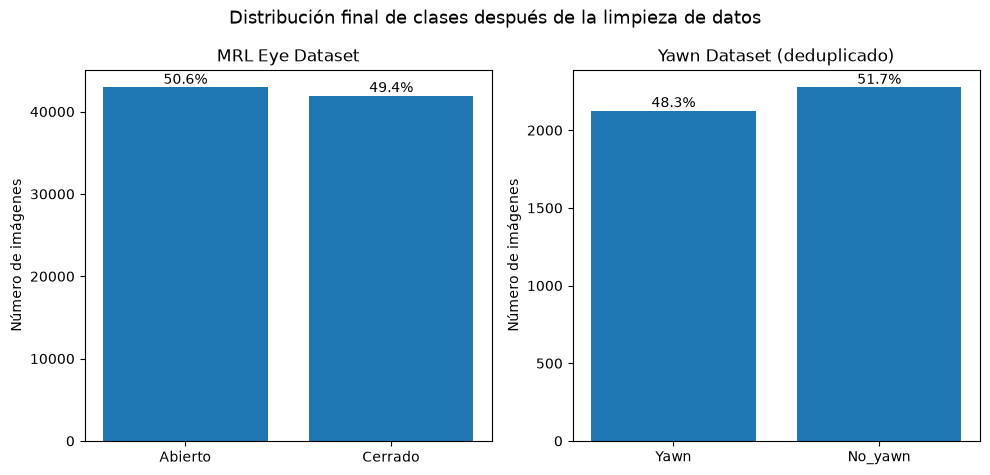


Figura guardada en: ..\results\fig_balance_clases_final.png


In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# RUTAS
# ============================================================

ruta_mrl = Path("../results/mrl_metadata.csv")
ruta_yawn = Path("../results/yawn_metadata_dedup.csv")

# ============================================================
# CARGAR DATOS
# ============================================================

df_mrl = pd.read_csv(ruta_mrl)
df_yawn = pd.read_csv(ruta_yawn)

# ============================================================
# MRL EYE
# columna esperada: ojo
# 1 = abierto, 0 = cerrado
# ============================================================

conteo_mrl = (
    df_mrl["ojo"]
    .map({1: "Abierto", 0: "Cerrado"})
    .value_counts()
    .reindex(["Abierto", "Cerrado"])
)

porc_mrl = conteo_mrl / conteo_mrl.sum() * 100

# ============================================================
# YAWN DATASET DEDUPLICADO
# columna esperada: clase
# valores esperados: yawn, no_yawn
# ============================================================

conteo_yawn = (
    df_yawn["clase"]
    .replace({
        "yawn": "Yawn",
        "no_yawn": "No_yawn"
    })
    .value_counts()
    .reindex(["Yawn", "No_yawn"])
)

porc_yawn = conteo_yawn / conteo_yawn.sum() * 100

# ============================================================
# MOSTRAR RESULTADOS EN TEXTO
# ============================================================

print("=== BALANCE DE CLASES ===\n")

print("MRL Eye Dataset")
for clase in conteo_mrl.index:
    print(f"{clase}: {conteo_mrl[clase]} ({porc_mrl[clase]:.1f}%)")

print("\nYawn Dataset (deduplicado)")
for clase in conteo_yawn.index:
    print(f"{clase}: {conteo_yawn[clase]} ({porc_yawn[clase]:.1f}%)")

# ============================================================
# FIGURA
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(10, 4.8))

# --- MRL ---
axes[0].bar(conteo_mrl.index, conteo_mrl.values)
axes[0].set_title("MRL Eye Dataset")
axes[0].set_ylabel("Número de imágenes")

for i, (n, p) in enumerate(zip(conteo_mrl.values, porc_mrl.values)):
    axes[0].text(i, n + max(conteo_mrl.values)*0.01, f"{p:.1f}%", ha="center")

# --- Yawn ---
axes[1].bar(conteo_yawn.index, conteo_yawn.values)
axes[1].set_title("Yawn Dataset (deduplicado)")
axes[1].set_ylabel("Número de imágenes")

for i, (n, p) in enumerate(zip(conteo_yawn.values, porc_yawn.values)):
    axes[1].text(i, n + max(conteo_yawn.values)*0.01, f"{p:.1f}%", ha="center")

fig.suptitle("Distribución final de clases después de la limpieza de datos", fontsize=13)
plt.tight_layout()

# Guardar figura
ruta_figura = Path("../results/fig_balance_clases_final.png")
plt.savefig(ruta_figura, dpi=300, bbox_inches="tight")

plt.show()

print(f"\nFigura guardada en: {ruta_figura}")

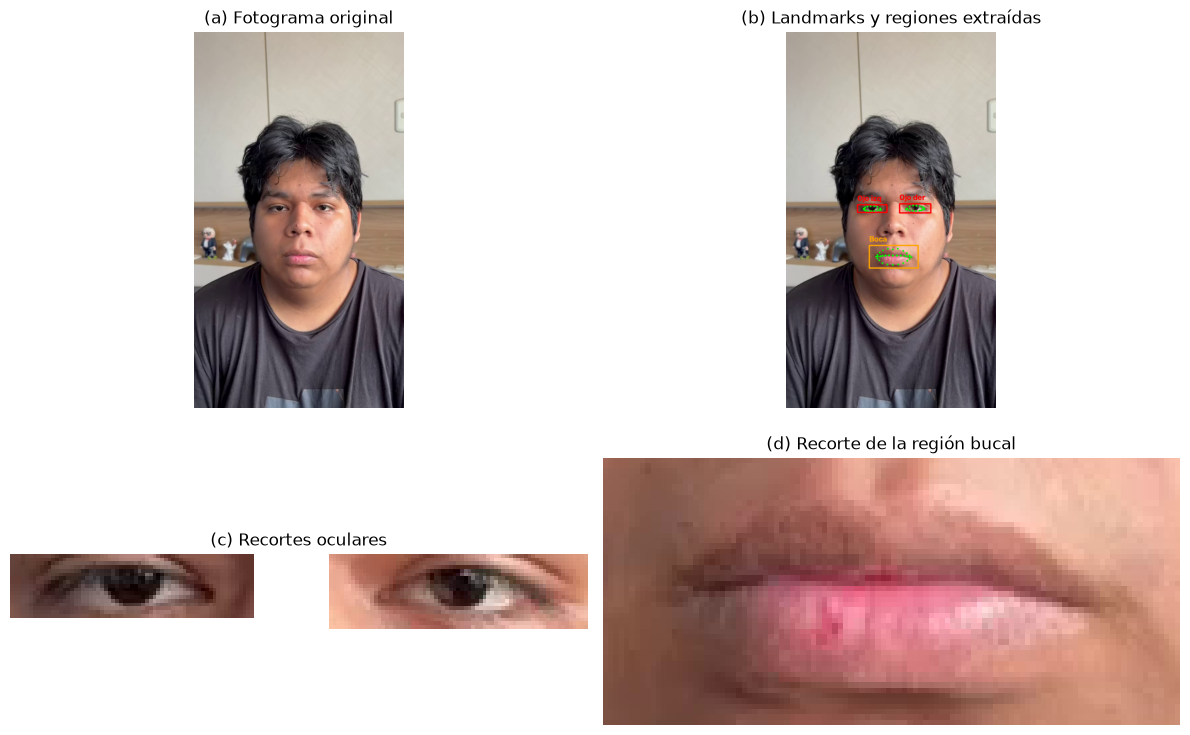

Figura guardada en: ..\results\fig_landmarks_recortes_G.png


In [12]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
import mediapipe as mp

# ===== RUTAS =====
ruta_video = Path("../data/raw/V6_video1_normal.mp4")
frame_objetivo = 1170
ruta_salida = Path("../results/fig_landmarks_recortes_G.png")

# ===== ÍNDICES =====
OJO_IZQ = [33,7,163,144,145,153,154,155,133,173,157,158,159,160,161,246]
OJO_DER = [362,382,381,380,374,373,390,249,263,466,388,387,386,385,384,398]

LABIOS = [61,146,91,181,84,17,314,405,321,375,291,185,40,39,37,0,
          267,269,270,409,78,95,88,178,87,14,317,402,318,324,308,
          191,80,81,82,13,312,311,310,415]

# ===== CARGAR FRAME =====
cap = cv2.VideoCapture(str(ruta_video))
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_objetivo)
ok, frame_bgr = cap.read()
cap.release()

if not ok:
    raise ValueError("No se pudo leer el frame del video.")

frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
h, w = frame_rgb.shape[:2]

# ===== DETECTOR MEDIAPIPE =====
candidatos = list(Path("../models").glob("*face*landmarker*.task"))
if len(candidatos) == 0:
    raise FileNotFoundError("No se encontró face_landmarker.task en ../models")

RUTA_FACE = candidatos[0]

BaseOptions = mp.tasks.BaseOptions
FaceLandmarker = mp.tasks.vision.FaceLandmarker
FaceLandmarkerOptions = mp.tasks.vision.FaceLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

opciones_face = FaceLandmarkerOptions(
    base_options=BaseOptions(model_asset_path=str(RUTA_FACE)),
    running_mode=VisionRunningMode.IMAGE,
    num_faces=1
)

detector = FaceLandmarker.create_from_options(opciones_face)

mp_image = mp.Image(
    image_format=mp.ImageFormat.SRGB,
    data=frame_rgb
)

resultado = detector.detect(mp_image)

if len(resultado.face_landmarks) == 0:
    raise ValueError("No se detectó rostro en el frame seleccionado.")

landmarks = resultado.face_landmarks[0]

# ===== FUNCIONES =====
def puntos_px(indices, landmarks, w, h):
    pts = []
    for i in indices:
        x = int(landmarks[i].x * w)
        y = int(landmarks[i].y * h)
        pts.append((x, y))
    return np.array(pts)

def caja_con_margen(pts, w, h, margen=0.35):
    x_min = np.min(pts[:, 0])
    y_min = np.min(pts[:, 1])
    x_max = np.max(pts[:, 0])
    y_max = np.max(pts[:, 1])

    ancho = x_max - x_min
    alto = y_max - y_min

    mx = int(ancho * margen)
    my = int(alto * margen)

    x1 = max(0, x_min - mx)
    y1 = max(0, y_min - my)
    x2 = min(w, x_max + mx)
    y2 = min(h, y_max + my)

    return x1, y1, x2, y2

# ===== PUNTOS =====
pts_ojo_izq = puntos_px(OJO_IZQ, landmarks, w, h)
pts_ojo_der = puntos_px(OJO_DER, landmarks, w, h)
pts_boca = puntos_px(LABIOS, landmarks, w, h)

# ===== CAJAS =====
box_ojo_izq = caja_con_margen(pts_ojo_izq, w, h, margen=0.35)
box_ojo_der = caja_con_margen(pts_ojo_der, w, h, margen=0.35)
box_boca = caja_con_margen(pts_boca, w, h, margen=0.20)

# ===== RECORTES =====
x1, y1, x2, y2 = box_ojo_izq
rec_ojo_izq = frame_rgb[y1:y2, x1:x2]

x1, y1, x2, y2 = box_ojo_der
rec_ojo_der = frame_rgb[y1:y2, x1:x2]

x1, y1, x2, y2 = box_boca
rec_boca = frame_rgb[y1:y2, x1:x2]

# ===== FRAME CON LANDMARKS =====
frame_overlay = frame_rgb.copy()

for pts in [pts_ojo_izq, pts_ojo_der, pts_boca]:
    for (x, y) in pts:
        cv2.circle(frame_overlay, (x, y), 2, (0, 255, 0), -1)

for box, color, texto in [
    (box_ojo_izq, (255, 0, 0), "Ojo izq"),
    (box_ojo_der, (255, 0, 0), "Ojo der"),
    (box_boca, (255, 165, 0), "Boca")
]:
    x1, y1, x2, y2 = box
    cv2.rectangle(frame_overlay, (x1, y1), (x2, y2), color, 2)
    cv2.putText(frame_overlay, texto, (x1, max(20, y1 - 8)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2, cv2.LINE_AA)

# ===== FIGURA =====
fig = plt.figure(figsize=(12, 8))

ax1 = plt.subplot(2, 2, 1)
ax1.imshow(frame_rgb)
ax1.set_title("(a) Fotograma original")
ax1.axis("off")

ax2 = plt.subplot(2, 2, 2)
ax2.imshow(frame_overlay)
ax2.set_title("(b) Landmarks y regiones extraídas")
ax2.axis("off")

ax3 = plt.subplot(2, 2, 3)
canvas_ojos = np.ones((max(rec_ojo_izq.shape[0], rec_ojo_der.shape[0]),
                       rec_ojo_izq.shape[1] + rec_ojo_der.shape[1] + 20, 3), dtype=np.uint8) * 255
canvas_ojos[:rec_ojo_izq.shape[0], :rec_ojo_izq.shape[1]] = rec_ojo_izq
canvas_ojos[:rec_ojo_der.shape[0], rec_ojo_izq.shape[1] + 20:rec_ojo_izq.shape[1] + 20 + rec_ojo_der.shape[1]] = rec_ojo_der
ax3.imshow(canvas_ojos)
ax3.set_title("(c) Recortes oculares")
ax3.axis("off")

ax4 = plt.subplot(2, 2, 4)
ax4.imshow(rec_boca)
ax4.set_title("(d) Recorte de la región bucal")
ax4.axis("off")

plt.tight_layout()
plt.savefig(ruta_salida, dpi=300, bbox_inches="tight")
plt.show()

print("Figura guardada en:", ruta_salida)